In [3]:
import sys
import os
notebook_dir = os.path.dirname(os.path.abspath(''))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))

## Diabetes Dataset

c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


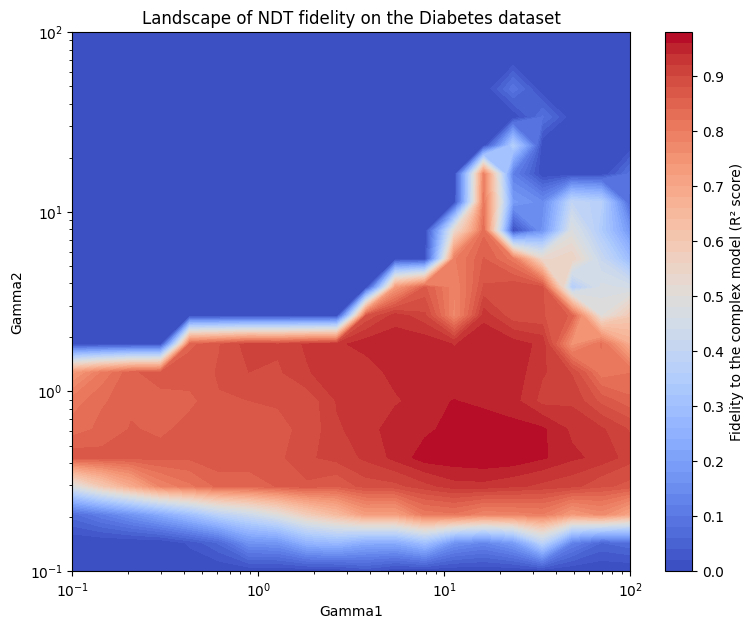

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from lime_ndt.lime_tabular import LimeNdtExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = load_diabetes()
X = data.data
y = data.target
feature_names = data.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)

# ========================
# Explainer NDT
# ========================
explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode="regression"
)

# ========================
# Fidélité locale avec perturbations
# ========================
def fidelity_local_model(instance, g1, g2, num_samples_train=5000, num_samples_test=2000):
    num_features = instance.shape[0]

    # Perturbations train
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)

    # Perturbations test
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)

    # Modèle local NDT
    local_model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], random_state=42)
    local_model.fit(Z_train, y_global_train)

    # Fidélité
    y_local_test = local_model.predict(Z_test)
    return r2_score(y_global_test, y_local_test)

# ========================
# Landscape (grille de gammas)
# ========================
gamma1_values = np.logspace(-1, 2, 20)   # de 0.1 à 100
gamma2_values = np.logspace(-1, 2, 20)

# Choisir une instance
instance = X_test[0]

# Évaluer en parallèle
scores = Parallel(n_jobs=-1)(
    delayed(fidelity_local_model)(instance, g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))

# ========================
# Plot du landscape
# ========================
scores_clipped = np.clip(scores, 0, 1)

plt.figure(figsize=(9,7))
cs = plt.contourf(
    gamma1_values,
    gamma2_values,
    scores_clipped,
    levels=50,
    cmap="coolwarm"
)
plt.colorbar(cs, label="Fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the Diabetes dataset")
plt.show()

## California Housing Dataset

c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


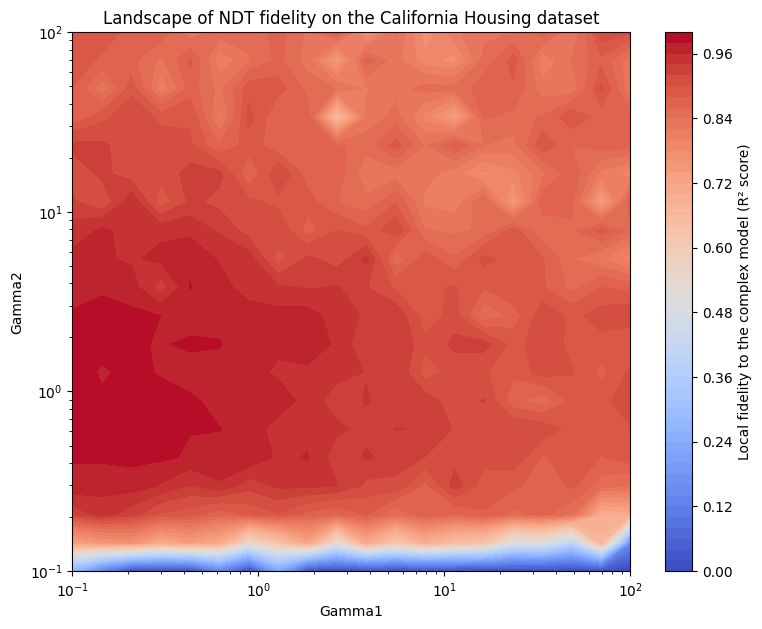

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from lime_ndt.lime_tabular import LimeNdtExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = fetch_california_housing()
X = data.data
y = data.target
feature_names = data.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    return mlp_global.predict(X)

# ========================
# Explainer NDT
# ========================
explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode="regression"
)

# ========================
# Fidélité locale avec perturbations
# ========================
def fidelity_local_model(instance, g1, g2, num_samples_train=5000, num_samples_test=2000):
    num_features = instance.shape[0]

    # Perturbations train
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)

    # Perturbations test
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)

    # Modèle local NDT
    local_model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], random_state=42)
    local_model.fit(Z_train, y_global_train)

    # Fidélité
    y_local_test = local_model.predict(Z_test)
    return r2_score(y_global_test, y_local_test)

# ========================
# Landscape (grille de gammas)
# ========================
gamma1_values = np.logspace(-1, 2, 20)   # de 0.1 à 100
gamma2_values = np.logspace(-1, 2, 20)

# Choisir une instance
instance = X_test[0]

# Évaluer en parallèle
scores = Parallel(n_jobs=-1)(
    delayed(fidelity_local_model)(instance, g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))
scores_clipped = np.clip(scores, 0, 1)

# ========================
# Plot du landscape
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(
    gamma1_values,
    gamma2_values,
    scores_clipped,
    levels=50,
    cmap="coolwarm"
)
plt.colorbar(cs, label="Local fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the California Housing dataset")
plt.show()

## Iris Dataset

c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


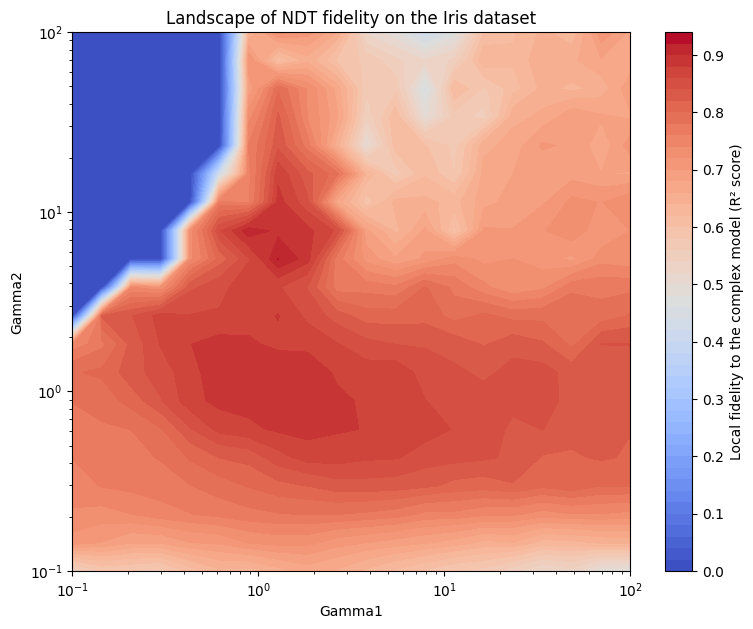

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPClassifier
from lime_ndt.lime_tabular import LimeNdtExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    # Retourner les labels prédits comme float, reshape en 2D
    return mlp_global.predict(X).astype(float).reshape(-1, 1)

# ========================
# Explainer NDT
# ========================
explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode="classification"
)

# ========================
# Fidélité locale avec perturbations
# ========================
def fidelity_local_model(instance, g1, g2, num_samples_train=5000, num_samples_test=2000, seed=42):
    np.random.seed(seed)
    num_features = instance.shape[0]

    # Perturbations train
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)

    # Perturbations test
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)

    # Modèle local NDT
    local_model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], random_state=seed)
    local_model.fit(Z_train, y_global_train)

    y_local_test = local_model.predict(Z_test)
    return r2_score(y_global_test, y_local_test)

# ========================
# Grille de gammas
# ========================
gamma1_values = np.logspace(-1, 2, 20)
gamma2_values = np.logspace(-1, 2, 20)

# Choisir une instance
instance = X_test[0]

# Évaluer en parallèle
scores = Parallel(n_jobs=-1)(
    delayed(fidelity_local_model)(instance, g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))
scores_clipped = np.clip(scores, 0, 1)

# ========================
# Plot du landscape
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(
    gamma1_values,
    gamma2_values,
    scores_clipped,
    levels=50,
    cmap="coolwarm"
)
plt.colorbar(cs, label="Local fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the Iris dataset")
plt.show()


## Breast Cancer Dataset

c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


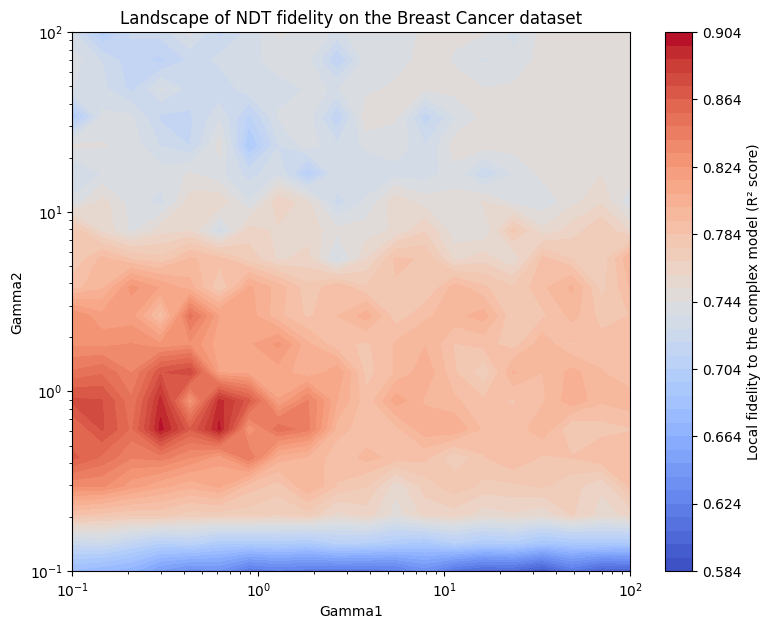

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPClassifier
from lime_ndt.lime_tabular import LimeNdtExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    # Retourner les labels prédits comme float, reshape en 2D
    return mlp_global.predict(X).astype(float).reshape(-1, 1)

# ========================
# Explainer NDT
# ========================
explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode="classification"
)

# ========================
# Fidélité locale avec perturbations
# ========================
def fidelity_local_model(instance, g1, g2, num_samples_train=5000, num_samples_test=2000, seed=42):
    np.random.seed(seed)
    num_features = instance.shape[0]

    # Perturbations train
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)

    # Perturbations test
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)

    # Modèle local NDT
    local_model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], random_state=seed)
    local_model.fit(Z_train, y_global_train)

    y_local_test = local_model.predict(Z_test)
    return r2_score(y_global_test, y_local_test)

# ========================
# Grille de gammas
# ========================
gamma1_values = np.logspace(-1, 2, 20)
gamma2_values = np.logspace(-1, 2, 20)

# Choisir une instance
instance = X_test[0]

# Évaluer en parallèle
scores = Parallel(n_jobs=-1)(
    delayed(fidelity_local_model)(instance, g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))
scores_clipped = np.clip(scores, 0, 1)

# ========================
# Plot du landscape
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(
    gamma1_values,
    gamma2_values,
    scores_clipped,
    levels=50,
    cmap="coolwarm"
)
plt.colorbar(cs, label="Local fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the Breast Cancer dataset")
plt.show()


## Wine Dataset

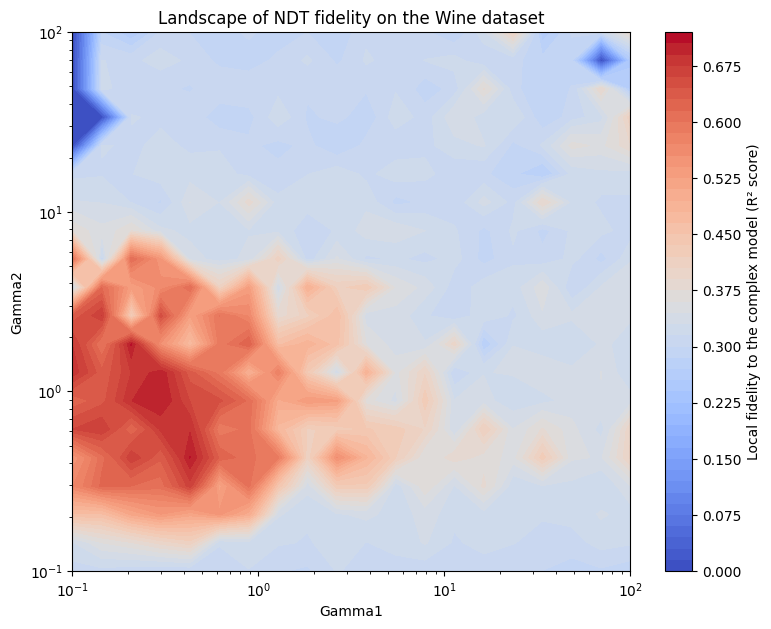

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPClassifier
from lime_ndt.lime_tabular import LimeNdtExplainer as LimeNDTExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper
from joblib import Parallel, delayed

# ========================
# Charger dataset
# ========================
data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ========================
# Modèle global (MLP)
# ========================
mlp_global = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)
mlp_global.fit(X_train, y_train)

def predict_fn(X):
    # Retourner les labels prédits comme float, reshape en 2D
    return mlp_global.predict(X).astype(float).reshape(-1, 1)

# ========================
# Explainer NDT
# ========================
explainer_ndt = LimeNDTExplainer(
    X_train,
    feature_names=feature_names,
    discretize_continuous=False,
    mode="classification"
)

# ========================
# Fidélité locale avec perturbations
# ========================
def fidelity_local_model(instance, g1, g2, num_samples_train=5000, num_samples_test=2000, seed=42):
    np.random.seed(seed)
    num_features = instance.shape[0]

    # Perturbations train
    Z_train = np.zeros((num_samples_train, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_train[:, i] = np.random.normal(mean, std, size=num_samples_train)
    y_global_train = predict_fn(Z_train)

    # Perturbations test
    Z_test = np.zeros((num_samples_test, num_features))
    for i in range(num_features):
        mean = instance[i]
        std = explainer_ndt.scaler.scale_[i] if hasattr(explainer_ndt.scaler, "scale_") else 0.01
        Z_test[:, i] = np.random.normal(mean, std, size=num_samples_test)
    y_global_test = predict_fn(Z_test)

    # Modèle local NDT
    local_model = NDTRegressorWrapper(D=X_train.shape[1], gammas=[g1, g2], random_state=seed)
    local_model.fit(Z_train, y_global_train)

    y_local_test = local_model.predict(Z_test)
    return r2_score(y_global_test, y_local_test)

# ========================
# Grille de gammas
# ========================
gamma1_values = np.logspace(-1, 2, 20)
gamma2_values = np.logspace(-1, 2, 20)

# Choisir une instance
instance = X_test[0]

# Évaluer en parallèle
scores = Parallel(n_jobs=-1)(
    delayed(fidelity_local_model)(instance, g1, g2)
    for g2 in gamma2_values
    for g1 in gamma1_values
)

scores = np.array(scores).reshape(len(gamma2_values), len(gamma1_values))
scores_clipped = np.clip(scores, 0, 1)

# ========================
# Plot du landscape
# ========================
plt.figure(figsize=(9,7))
cs = plt.contourf(
    gamma1_values,
    gamma2_values,
    scores_clipped,
    levels=50,
    cmap="coolwarm"
)
plt.colorbar(cs, label="Local fidelity to the complex model (R² score)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Gamma1")
plt.ylabel("Gamma2")
plt.title("Landscape of NDT fidelity on the Wine dataset")
plt.show()
